# Experimentación con LSTM 

Experimentaremos con una red neuronal LSTM para comparar los mecanismos de memoria a corto y largo plazo

1. Importamos librerias

In [6]:
import pandas as pd
import numpy as np
import sys
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM, Reshape
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

sys.path.append(os.path.abspath("../Code"))
import vectorize

import gensim.downloader
from gensim.models.fasttext import load_facebook_model

2. Declaramos variables iniciales, destaca DATA_PATHS, guardando todos los csv con los que se va a experimentar y vectorizadores, con todos los tipos de representaciones vectoriales que se utilizarán

In [7]:
DATA_PATHS = [
    '../Data/raw/tcga_simple_train.csv',
    '../Data/interim/tcga_simple_train_preprocessed_0.csv', 
    '../Data/interim/tcga_simple_train_preprocessed_1.csv',
    '../Data/interim/tcga_simple_train_preprocessed_2.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3.csv',
    '../Data/interim/tcga_simple_train_preprocessed_4.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3_augmented.csv',
]
RESULTS_PATH = '../Results/Metrics/lstm.csv'
MAX_LEN = 512
vectorizadores = ["Binaria", "Frecuencia", "Tfidf", "Word2Vec", "FastText"]

3. Cargamos los modelos de embeddings estáticos:

In [ ]:
w2v_model = gensim.downloader.load('word2vec-google-news-300')
fasttext_model = load_facebook_model("../Models/wiki.simple.bin") # Es necesario tener el modelo descargado

In [ ]:
4. Declaramos la red neuronal y funciones auxiliares:

In [9]:
def texto_a_secuencia(serie_texto, mapping, max_len):
    sequencias = []
    for texto in serie_texto:
        seq = [mapping[w] for w in str(texto).split() if w in mapping]
        sequencias.append(seq)
    return pad_sequences(sequencias, maxlen=max_len)


def limpiar_dataframe_texto_etiqueta(df, text_col='text', label_col='t', dataset_name=''):
    """
    Limpia el dataframe antes de entrenar:
    - elimina filas sin texto o sin etiqueta;
    - convierte el texto a string real;
    - elimina textos vacíos o valores tipo 'nan', 'none', 'null'.

    Esto evita errores de CountVectorizer como:
    ValueError: np.nan is an invalid document.
    """
    df = df.copy()

    if text_col not in df.columns or label_col not in df.columns:
        raise KeyError(
            f"El dataset {dataset_name} debe tener las columnas '{text_col}' y '{label_col}'. "
            f"Columnas encontradas: {list(df.columns)}"
        )

    filas_iniciales = len(df)

    # 1) Quitamos etiquetas nulas
    df = df.dropna(subset=[label_col]).copy()

    # 2) Marcamos como nulos textos vacíos o strings típicos de nulo
    df[text_col] = df[text_col].replace(r'^\s*$', np.nan, regex=True)
    df[text_col] = df[text_col].replace(['nan', 'NaN', 'None', 'none', 'NULL', 'null'], np.nan)

    # 3) Quitamos textos nulos y convertimos a string limpio
    df = df.dropna(subset=[text_col]).copy()
    df[text_col] = df[text_col].astype(str).str.strip()

    # 4) Por seguridad, eliminamos los textos que hayan quedado vacíos tras strip()
    df = df[df[text_col].ne('')].copy().reset_index(drop=True)

    filas_eliminadas = filas_iniciales - len(df)
    if filas_eliminadas > 0:
        print(f"Filas eliminadas por texto/etiqueta vacía en {dataset_name}: {filas_eliminadas}")

    return df

def build_lstm_model(input_type, vocab_size=None, input_dim=None):
    model = Sequential()
    
    if input_type == 'secuencia':
        model.add(Embedding(input_dim=vocab_size + 1, output_dim=16, input_length=MAX_LEN))
    else:
        model.add(Reshape((1, input_dim), input_shape=(input_dim,)))
        
    model.add(LSTM(units=8, activation='tanh', dropout=0.6, recurrent_dropout=0))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

resultados = []

# Guardamos también las predicciones del mejor modelo para la matriz de confusión
best_predictions = None
best_true_labels = None
best_label_encoder = None
best_f1 = -1
best_model_info = {}

5. Realizamos los experimentos

In [10]:
for data_path in DATA_PATHS:
    dataset_name = os.path.basename(data_path)
    print(f"PROCESANDO DATASET: {dataset_name}\n")

    # 1. Cargar dataset
    df = pd.read_csv(data_path)

    # 2. Gestionar nulos antes de separar train/test
    #    Importante: si dejamos NaN en 'text', CountVectorizer falla.
    df = limpiar_dataframe_texto_etiqueta(
        df,
        text_col='text',
        label_col='t',
        dataset_name=dataset_name
    )

    # Si tras limpiar no queda información suficiente, omitimos ese dataset
    if df.empty:
        print(f"Dataset vacío tras la limpieza: {dataset_name}. Se omite.\n")
        continue

    if df['t'].nunique() < 2:
        print(f"Dataset con menos de 2 clases tras la limpieza: {dataset_name}. Se omite.\n")
        continue

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        df['text'],
        df['t'],
        test_size=0.2,
        random_state=23
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=33
    )

    le = LabelEncoder()
    y_train_num = le.fit_transform(y_train)
    y_val_num = le.transform(y_val)
    y_test_num = le.transform(y_test)

    for nombre_vec in vectorizadores:
        print(f" -> Evaluando LSTM con vectorización: {nombre_vec}...")

        try:
            # 1. Preparación de entradas
            if nombre_vec in ["Binaria", "Frecuencia", "Tfidf"]:

                if nombre_vec == "Binaria":
                    _, v = vectorize.vectorizacionBinaria(X_train)
                elif nombre_vec == "Frecuencia":
                    _, v = vectorize.vectorizacionFreq(X_train)
                else:
                    _, v = vectorize.vectorizacionTfidf(X_train)

                vocab_map = v.vocabulary_
                index_mapping = {word: (idx + 1) for word, idx in vocab_map.items()}

                X_train_nn = texto_a_secuencia(X_train, index_mapping, MAX_LEN)
                X_val_nn = texto_a_secuencia(X_val, index_mapping, MAX_LEN)
                X_test_nn = texto_a_secuencia(X_test, index_mapping, MAX_LEN)

                num_words = len(v.get_feature_names_out()) + 1
                model = build_lstm_model('secuencia', vocab_size=num_words)

            elif nombre_vec == "Word2Vec":
                X_train_nn = vectorize.vectorizacionEmbeddings(X_train, w2v_model)
                X_val_nn = vectorize.vectorizacionEmbeddings(X_val, w2v_model)
                X_test_nn = vectorize.vectorizacionEmbeddings(X_test, w2v_model)

                input_dim = X_train_nn.shape[2] if len(X_train_nn.shape) > 2 else X_train_nn.shape[1]
                model = build_lstm_model('embedding', input_dim=input_dim)

            elif nombre_vec == "FastText":
                X_train_nn = vectorize.vectorizacionEmbeddings(X_train, fasttext_model)
                X_val_nn = vectorize.vectorizacionEmbeddings(X_val, fasttext_model)
                X_test_nn = vectorize.vectorizacionEmbeddings(X_test, fasttext_model)

                input_dim = X_train_nn.shape[2] if len(X_train_nn.shape) > 2 else X_train_nn.shape[1]
                model = build_lstm_model('embedding', input_dim=input_dim)

            early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

            history = model.fit(
                X_train_nn, y_train_num,
                epochs=30,
                batch_size=64,
                validation_data=(X_val_nn, y_val_num),
                callbacks=[early_stop],
                verbose=0
            )

            # 3. Evaluación
            predicciones_prob = model.predict(X_test_nn, verbose=0)
            clases_predichas = np.argmax(predicciones_prob, axis=1)
            macro_f1 = f1_score(y_test_num, clases_predichas, average='macro')

            # 4. Guardar resultado con Dataset ID
            resultados.append({
                "Dataset": dataset_name,
                "Vectorizacion": nombre_vec,
                "Macro_F1": round(macro_f1, 4)
            })

            print(f"F1 Macro: {macro_f1:.4f}")

            # Guardamos info del mejor modelo para la matriz de confusión
            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_predictions = clases_predichas
                best_true_labels = y_test_num
                best_label_encoder = le
                best_model_info = {"Dataset": dataset_name, "Vectorizacion": nombre_vec}

        except Exception as e:
            print(f"Error con {dataset_name} + {nombre_vec}: {type(e).__name__}: {e}")
            print("Se continúa con la siguiente configuración.\n")

        finally:
            tf.keras.backend.clear_session()

# 5. Exportar a CSV
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
os.makedirs('../Results/Figures', exist_ok=True)

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(RESULTS_PATH, index=False)
print(df_resultados.head())

PROCESANDO DATASET: tcga_simple_train.csv

 -> Evaluando LSTM con vectorización: Binaria...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


F1 Macro: 0.4127
 -> Evaluando LSTM con vectorización: Frecuencia...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


F1 Macro: 0.4011
 -> Evaluando LSTM con vectorización: Tfidf...


...

F1 Macro: 0.4684
 -> Evaluando LSTM con vectorización: Word2Vec...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


F1 Macro: 0.5665
 -> Evaluando LSTM con vectorización: FastText...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


F1 Macro: 0.5583
                 Dataset Vectorizacion  Macro_F1
0  tcga_simple_train.csv       Binaria    0.4127
1  tcga_simple_train.csv    Frecuencia    0.4011
2  tcga_simple_train.csv         Tfidf    0.2727
3  tcga_simple_train.csv      Word2Vec    0.4036
4  tcga_simple_train.csv      FastText    0.3570


## Matriz de confusión — mejor configuración

Una vez terminado el entrenamiento, vemos qué combinación de dataset + vectorización obtuvo el mayor F1 Macro y le sacamos la matriz de confusión. Así podemos ver no solo el número global sino *dónde* se equivoca el modelo (qué clases confunde más entre sí).

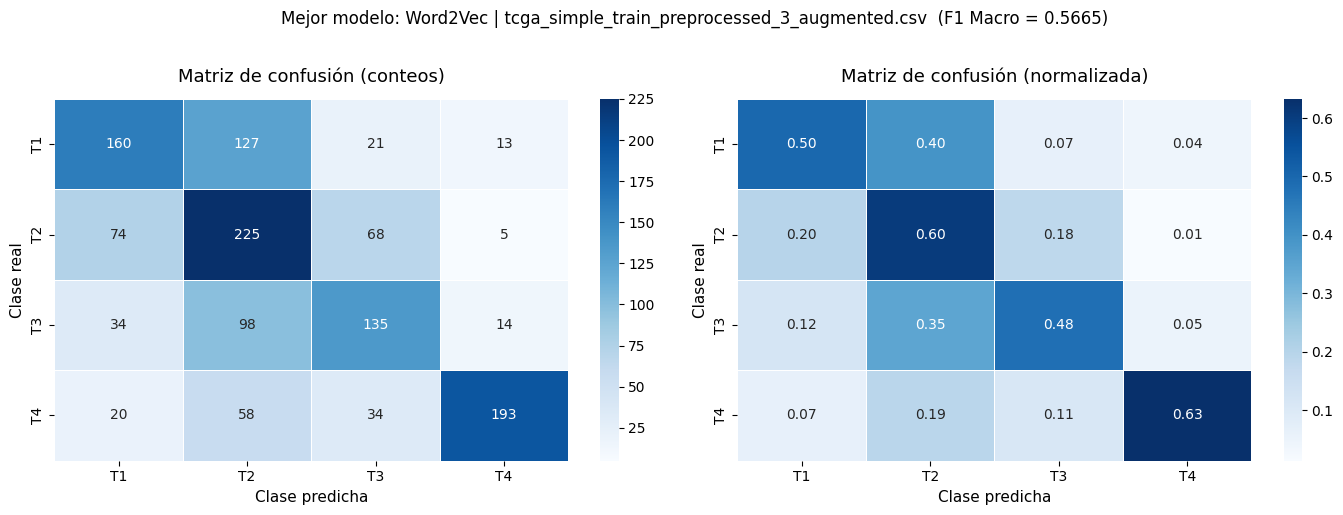

Figura guardada en Results/Figures/lstm_confusion_matrix.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import confusion_matrix

if best_true_labels is None or best_predictions is None:
    raise ValueError("No hay predicciones guardadas. Ejecuta primero la celda de entrenamiento.")

cm = confusion_matrix(best_true_labels, best_predictions)

# Normalizamos por fila para ver proporciones (más útil con clases desbalanceadas)
# np.divide evita NaN si alguna fila suma 0.
cm_norm = np.divide(
    cm.astype(float),
    cm.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm, dtype=float),
    where=cm.sum(axis=1, keepdims=True) != 0
)

class_names = best_label_encoder.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Matriz de confusión (conteos)', 'Matriz de confusión (normalizada)']
):
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Clase predicha', fontsize=11)
    ax.set_ylabel('Clase real', fontsize=11)

fig.suptitle(
    f"Mejor modelo: {best_model_info['Vectorizacion']} | {best_model_info['Dataset']}  (F1 Macro = {best_f1:.4f})",
    fontsize=12, y=1.02
)
plt.tight_layout()
os.makedirs('../Results/Figures', exist_ok=True)
plt.savefig('../Results/Figures/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en Results/Figures/lstm_confusion_matrix.png")

## Comparativa de vectorizaciones por dataset

Aquí pintamos un gráfico de barras agrupadas con el F1 Macro de cada vectorización para cada dataset. El objetivo es ver de un vistazo qué vectorización funciona mejor y si el preprocesado / augmentation ayuda o no. 

Spoiler: la representación binaria con secuencias suele ganar porque la LSTM puede aprovechar el orden de los tokens, mientras que los embeddings promediados colapsan toda la secuencia en un único vector y pierden esa información posicional.

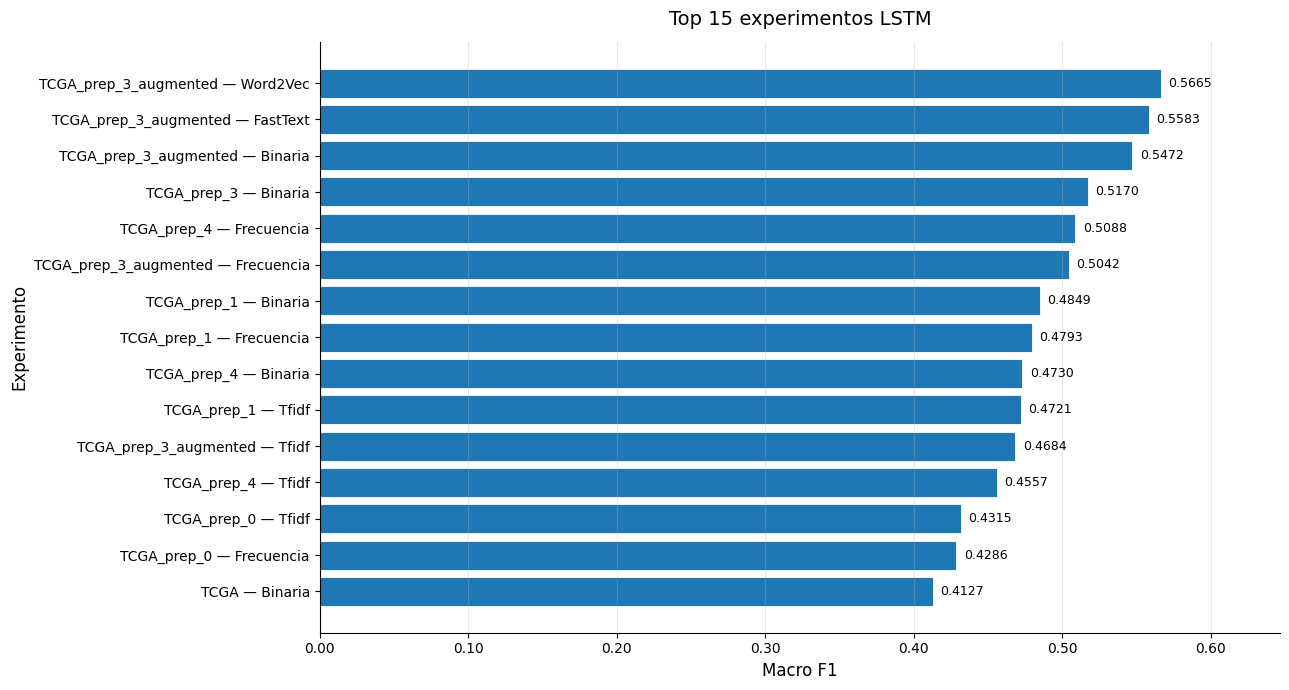

Figura guardada en ../Results/Figures/lstm_top15_experimentos.png


In [13]:
# Comparativa LSTM: Top 15 experimentos por F1 Macro

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

if 'df_resultados' not in globals() or df_resultados.empty:
    raise ValueError(
        "df_resultados no existe o está vacío. Ejecuta primero la celda de entrenamiento/evaluación."
    )

os.makedirs('../Results/Figures', exist_ok=True)

df_plot = df_resultados.copy()

# Aseguramos que Macro_F1 sea numérico
df_plot['Macro_F1'] = pd.to_numeric(df_plot['Macro_F1'], errors='coerce')
df_plot = df_plot.dropna(subset=['Macro_F1'])

# Etiquetas cortas para que el eje Y no quede enorme
df_plot['Dataset_corto'] = (
    df_plot['Dataset']
    .astype(str)
    .str.replace('tcga_simple_train', 'TCGA', regex=False)
    .str.replace('_preprocessed_', '_prep_', regex=False)
    .str.replace('.csv', '', regex=False)
)

# Nombre del experimento: dataset + vectorización
df_plot['Experimento'] = (
    df_plot['Dataset_corto'].astype(str)
    + ' — '
    + df_plot['Vectorizacion'].astype(str)
)

# Seleccionamos los mejores experimentos
top_n = 15

df_top = (
    df_plot
    .sort_values('Macro_F1', ascending=False)
    .head(top_n)
    .sort_values('Macro_F1', ascending=True)
)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    df_top['Experimento'],
    df_top['Macro_F1'],
    edgecolor='white',
    linewidth=0.6
)

# Valor numérico al final de cada barra
for bar in bars:
    value = bar.get_width()
    ax.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        va='center',
        ha='left',
        fontsize=9
    )

ax.set_xlabel('Macro F1', fontsize=12)
ax.set_ylabel('Experimento', fontsize=12)
ax.set_title(f'Top {top_n} experimentos LSTM', fontsize=14, pad=12)

# Límite del eje X ajustado automáticamente
max_f1 = df_top['Macro_F1'].max()
ax.set_xlim(0, min(1.0, max_f1 + 0.08))

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.grid(axis='x', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.savefig('../Results/Figures/lstm_top15_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figura guardada en ../Results/Figures/lstm_top15_experimentos.png")

## Conclusiones rápidas

- La vectorización **Binaria** tiende a ser la que mejor funciona dentro de las representaciones basadas en vocabulario. Tiene sentido: al convertir el texto a una secuencia de índices la LSTM puede trabajar con el orden de las palabras, que es justo para lo que está diseñada.
- Las vectorizaciones de **embeddings promediados** (Word2Vec y FastText) comprimen toda la secuencia en un único vector de longitud fija, por lo que la LSTM básicamente solo procesa un "paso" y pierde la ventaja temporal. Para exprimir los embeddings habría que hacer la secuencia token a token.
- El dataset **augmentado** mejora algo los resultados en comparación con el raw, lo que sugiere que el aumento de datos sí ayuda aunque el efecto no es dramático.
- En general los F1 no son muy altos; habría que explorar LSTMs bidireccionales o modelos basados en transformers para este tipo de texto clínico.